In [31]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from analysis import EDA

In [22]:
df = pd.read_csv("D:\Internship_projects\\biome-internship-projects\\Task4\\data\\diabetic_data.csv")
eda = EDA(df)

<>:1: SyntaxWarning: invalid escape sequence '\I'
<>:1: SyntaxWarning: invalid escape sequence '\I'
C:\Users\ELITEBOOK\AppData\Local\Temp\ipykernel_21560\2689047214.py:1: SyntaxWarning: invalid escape sequence '\I'
  df = pd.read_csv("D:\Internship_projects\\biome-internship-projects\\Task4\\data\\diabetic_data.csv")


In [10]:
df.head()

,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),?,6,25,1,1,...,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),?,1,1,7,3,...,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),?,1,1,7,2,...,No,No,No,No,No,No,No,No,Yes,NO
3,500364,82442376,Caucasian,Male,[30-40),?,1,1,7,2,...,No,Up,No,No,No,No,No,Ch,Yes,NO
4,16680,42519267,Caucasian,Male,[40-50),?,1,1,7,1,...,No,Steady,No,No,No,No,No,Ch,Yes,NO


In [11]:
print(eda.missing_value_report())

                     Feature  Missing Count  Missing Percentage
0              max_glu_serum          96420               94.75
1                  A1Cresult          84748               83.28
2                       race              0                0.00
3                     gender              0                0.00
4                        age              0                0.00
5                     weight              0                0.00
6          admission_type_id              0                0.00
7   discharge_disposition_id              0                0.00
8        admission_source_id              0                0.00
9           time_in_hospital              0                0.00
10                payer_code              0                0.00
11         medical_specialty              0                0.00
12        num_lab_procedures              0                0.00
13            num_procedures              0                0.00
14           num_medications            

In [15]:
print(eda.duplicated_report())

{'Total Rows': 101766, 'Duplicate Rows': np.int64(0), 'Duplicate Percentage': np.float64(0.0)}


In [26]:
print(eda.feature_summary("readmitted"))
print(eda.value_distribution("readmitted"))

{'Feature': 'readmitted', 'Data Type': 'str', 'Total Values': 101766, 'Unique Values': 3, 'Missing Count': np.int64(0), 'Missing Percentage': np.float64(0.0), 'Question Mark Count': np.int64(0), 'Most Frequent Value': 'NO', 'Most Frequent Count': np.int64(54864)}
  Value  Count  Percentage
0    NO  54864       53.91
1   >30  35545       34.93
2   <30  11357       11.16


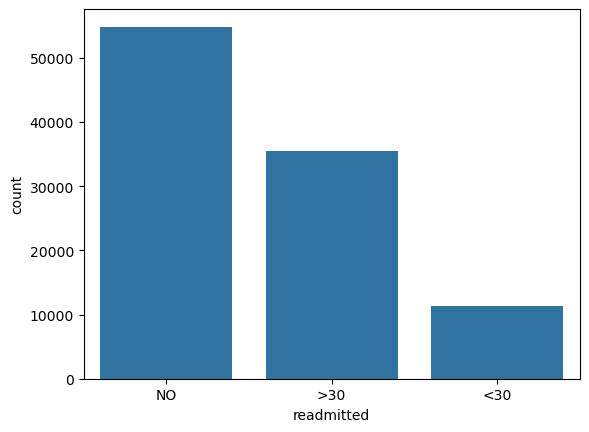

In [25]:
eda.plot_countplot("readmitted")

In [29]:
for feature in df.columns:
    summary = eda.feature_summary(feature)

    for key, value in summary.items():
        print(f"{key}: {value}")

    print("-" * 80)

Feature: encounter_id
Data Type: int64
Total Values: 101766
Unique Values: 101766
Missing Count: 0
Missing Percentage: 0.0
Question Mark Count: 0
Most Frequent Value: 12522
Most Frequent Count: 1
--------------------------------------------------------------------------------
Feature: patient_nbr
Data Type: int64
Total Values: 101766
Unique Values: 71518
Missing Count: 0
Missing Percentage: 0.0
Question Mark Count: 0
Most Frequent Value: 88785891
Most Frequent Count: 40
--------------------------------------------------------------------------------
Feature: race
Data Type: str
Total Values: 101766
Unique Values: 6
Missing Count: 0
Missing Percentage: 0.0
Question Mark Count: 2273
Most Frequent Value: Caucasian
Most Frequent Count: 76099
--------------------------------------------------------------------------------
Feature: gender
Data Type: str
Total Values: 101766
Unique Values: 3
Missing Count: 0
Missing Percentage: 0.0
Question Mark Count: 0
Most Frequent Value: Female
Most Frequ

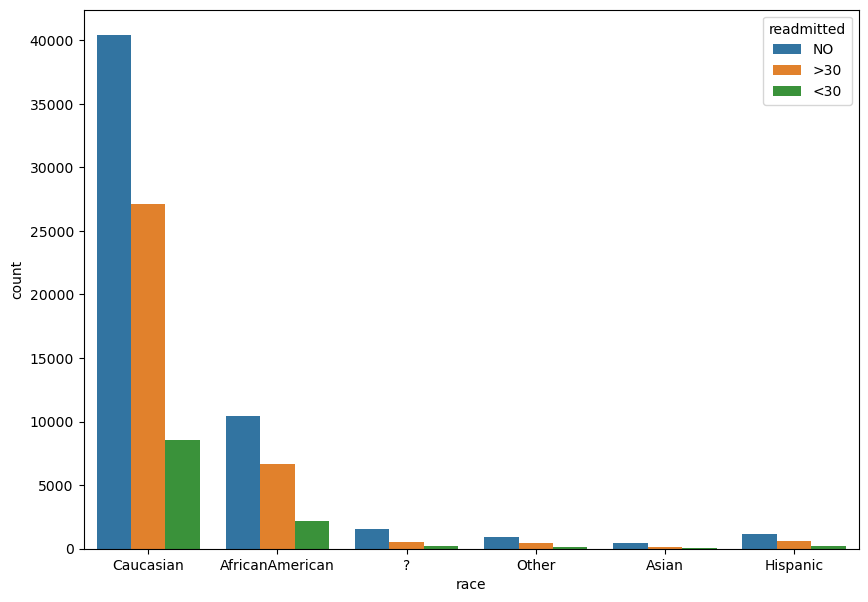

In [34]:
plt.figure(figsize=(10,7))
sns.countplot(data=df, x = 'race', hue="readmitted")
plt.show()

In [30]:
pd.crosstab(
    df["race"],
    df["readmitted"],
    normalize="index"
)

readmitted,<30,>30,NO
race,,,
?,0.082710,0.236692,0.680598
AfricanAmerican,0.112181,0.345341,0.542478
Asian,0.101404,0.251170,0.647426
Caucasian,0.112906,0.356430,0.530664
Hispanic,0.104075,0.315169,0.580756
Other,0.096282,0.296149,0.607570


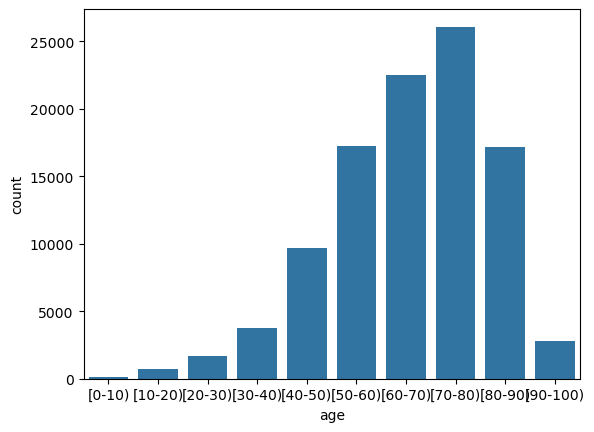

In [36]:
eda.plot_countplot("age")

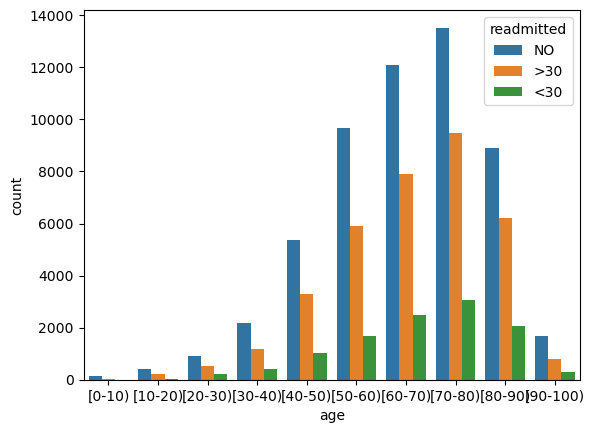

In [39]:
plt.Figure(figsize=(10,7))
sns.countplot(data=df, x= "age", hue="readmitted")
plt.show()

In [40]:
pd.crosstab(
    df['age'],
    df['readmitted'],
    normalize="index"
)

readmitted,<30,>30,NO
age,,,
[0-10),0.018634,0.161491,0.819876
[10-20),0.057887,0.324168,0.617945
[20-30),0.142426,0.307785,0.549789
[30-40),0.112318,0.314437,0.573245
[40-50),0.106040,0.338462,0.555498
[50-60),0.096662,0.342895,0.560443
[60-70),0.111284,0.351243,0.537473
[70-80),0.117731,0.363472,0.518797
[80-90),0.120835,0.361865,0.517300


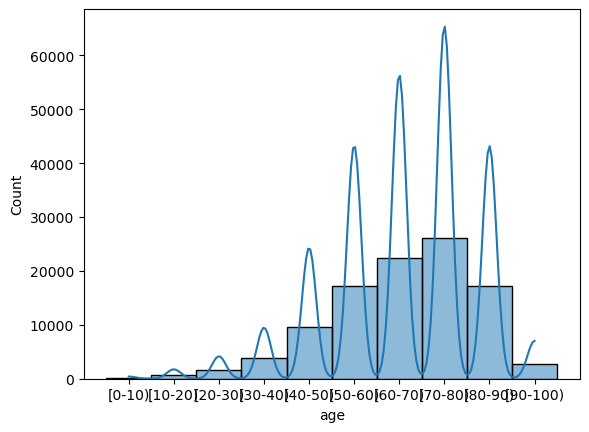

In [41]:
eda.plot_histogram("age")

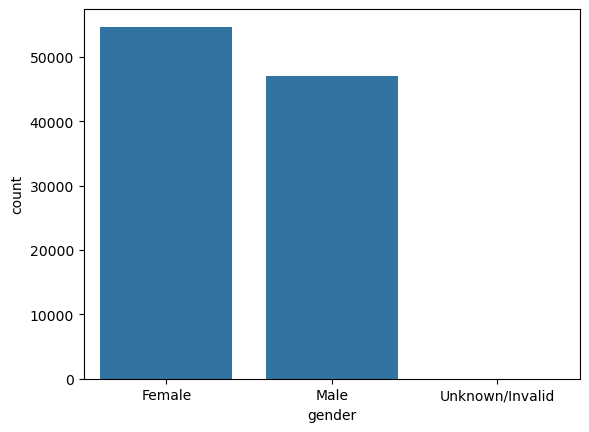

In [42]:
eda.plot_countplot("gender")

In [43]:
pd.crosstab(
    df['gender'],
    df["readmitted"],
    normalize="index"
)

readmitted,<30,>30,NO
gender,,,
Female,0.112452,0.356767,0.530782
Male,0.110615,0.340601,0.548783
Unknown/Invalid,0.000000,0.000000,1.000000


Unknown/Invalid cate should be droped in pre_processing

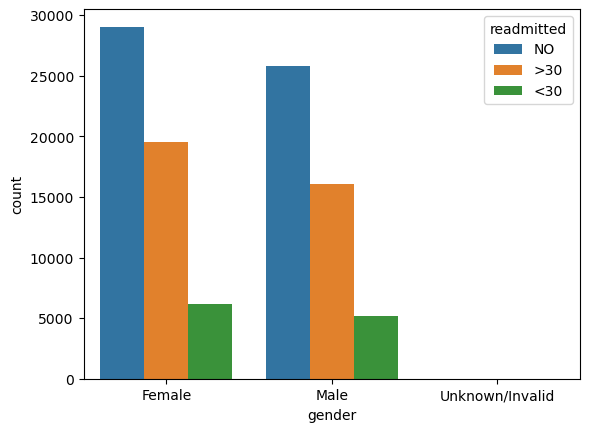

In [44]:
plt.Figure(figsize=(10,7))
sns.countplot(data=df, x= "gender", hue="readmitted")
plt.show()

In [45]:
eda.value_distribution("gender")

,Value,Count,Percentage
0,Female,54708,53.76
1,Male,47055,46.24
2,Unknown/Invalid,3,0.00


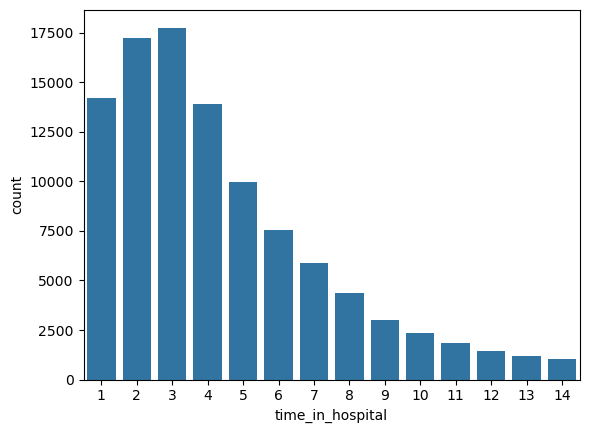

In [47]:
eda.plot_countplot("time_in_hospital")

In [48]:
pd.crosstab(
    df['time_in_hospital'],
    df["readmitted"],
    normalize="index"
)

readmitted,<30,>30,NO
time_in_hospital,,,
1,0.081785,0.314682,0.603533
2,0.099396,0.343648,0.556955
3,0.106668,0.342701,0.550631
4,0.118070,0.363689,0.518242
5,0.120309,0.359823,0.519868
6,0.125879,0.365433,0.508688
7,0.128350,0.362349,0.509302
8,0.142337,0.361877,0.495787
9,0.137242,0.366089,0.496669


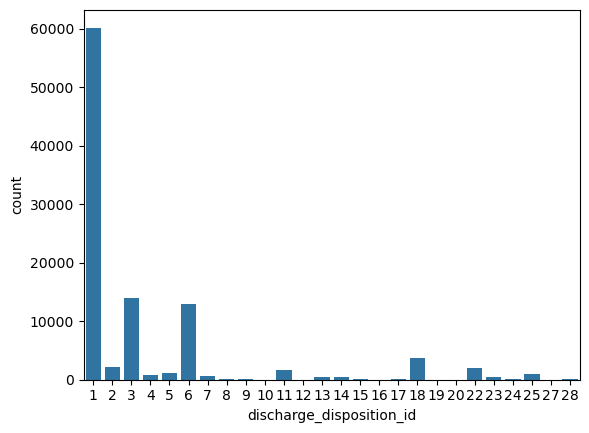

In [49]:
eda.plot_countplot("discharge_disposition_id")

In [50]:
pd.crosstab(
    df['discharge_disposition_id'],
    df["readmitted"],
    normalize="index"
)

readmitted,<30,>30,NO
discharge_disposition_id,,,
1,0.093004,0.357223,0.549773
2,0.160714,0.313910,0.525376
3,0.146625,0.352300,0.501075
4,0.127607,0.341104,0.531288
5,0.208615,0.295608,0.495777
6,0.126957,0.415594,0.457448
7,0.144462,0.354735,0.500803
8,0.138889,0.351852,0.509259
9,0.428571,0.095238,0.476190


Several discharge disposition categories correspond to deceased patients (e.g., Expired, Expired at Home, Expired in Medical Facility). These records have a 100% 'NO' readmission rate because deceased patients cannot be readmitted. This subset should be reviewed during preprocessing to determine whether exclusion is appropriate for the prediction task.

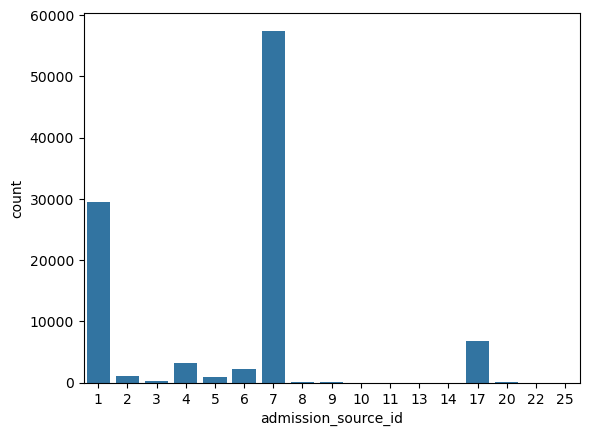

In [51]:
eda.plot_countplot("admission_source_id")

In [53]:
eda.value_distribution("admission_source_id")

,Value,Count,Percentage
0,7,57494,56.50
1,1,29565,29.05
2,17,6781,6.66
3,4,3187,3.13
4,6,2264,2.22
5,2,1104,1.08
6,5,855,0.84
7,3,187,0.18
8,20,161,0.16
9,9,125,0.12


In [52]:
pd.crosstab(
    df["admission_source_id"],
    df["readmitted"],
    normalize="index"
)

readmitted,<30,>30,NO
admission_source_id,,,
1,0.105868,0.326061,0.568070
2,0.100543,0.280797,0.618659
3,0.155080,0.310160,0.534759
4,0.096956,0.210857,0.692187
5,0.118129,0.276023,0.605848
6,0.093640,0.175795,0.730565
7,0.116882,0.376857,0.506262
8,0.125000,0.250000,0.625000
9,0.104000,0.128000,0.768000


there are some cat ids 11, 13,14 and 25 which are rare so i will add this into anther cate that is other

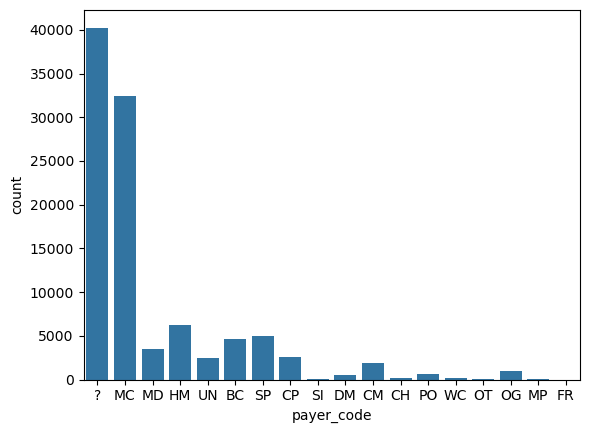

In [54]:
eda.plot_countplot("payer_code")

In [55]:
pd.crosstab(
    df["payer_code"],
    df["readmitted"],
    normalize="index"
)

readmitted,<30,>30,NO
payer_code,,,
?,0.114939,0.343502,0.541559
BC,0.091515,0.279484,0.629001
CH,0.089041,0.226027,0.684932
CM,0.102220,0.341249,0.556531
CP,0.084485,0.308330,0.607185
DM,0.116576,0.400729,0.482696
FR,0.000000,0.000000,1.000000
HM,0.102646,0.369780,0.527574
MC,0.117451,0.369370,0.513179


In [56]:
eda.value_distribution("payer_code")

,Value,Count,Percentage
0,?,40256,39.56
1,MC,32439,31.88
2,HM,6274,6.17
3,SP,5007,4.92
4,BC,4655,4.57
5,MD,3532,3.47
6,CP,2533,2.49
7,UN,2448,2.41
8,CM,1937,1.90
9,OG,1033,1.02


handle ? , missing vals, and grp cH, WC, OT,MP,SI and FR into other cateogory

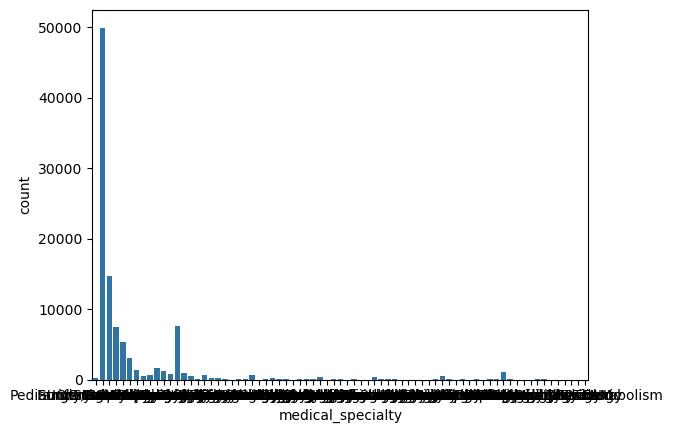

In [57]:
eda.plot_countplot("medical_specialty")

In [58]:
eda.value_distribution("medical_specialty")

,Value,Count,Percentage
0,?,49949,49.08
1,InternalMedicine,14635,14.38
2,Emergency/Trauma,7565,7.43
3,Family/GeneralPractice,7440,7.31
4,Cardiology,5352,5.26
...,...,...,...
68,Dermatology,1,0.00
69,SportsMedicine,1,0.00
70,Speech,1,0.00
71,Perinatology,1,0.00


In [59]:
pd.crosstab(
    df["medical_specialty"],
    df["readmitted"],
    normalize="index"
)

readmitted,<30,>30,NO
medical_specialty,,,
?,0.115738,0.364692,0.519570
AllergyandImmunology,0.428571,0.428571,0.142857
Anesthesiology,0.083333,0.250000,0.666667
Anesthesiology-Pediatric,0.052632,0.263158,0.684211
Cardiology,0.079410,0.346226,0.574365
...,...,...,...
Surgery-PlasticwithinHeadandNeck,0.000000,1.000000,0.000000
Surgery-Thoracic,0.100917,0.275229,0.623853
Surgery-Vascular,0.138837,0.375235,0.485929


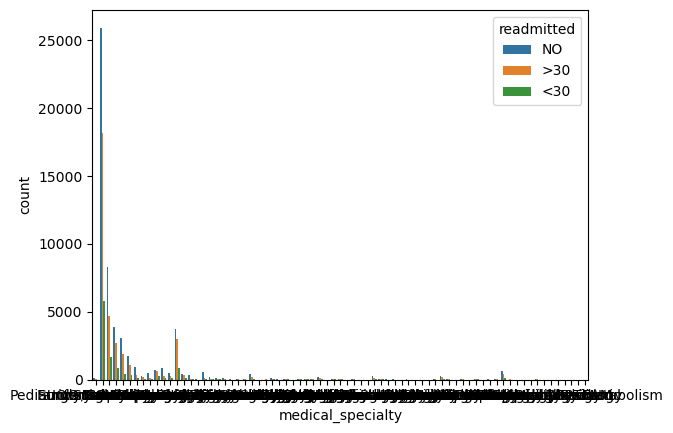

In [60]:
plt.Figure(figsize=(10,7))
sns.countplot(data=df, x="medical_specialty", hue="readmitted")
plt.show()

In [61]:
eda.feature_summary("medical_specialty")

{'Feature': 'medical_specialty',
 'Data Type': 'str',
 'Total Values': 101766,
 'Unique Values': 73,
 'Missing Count': np.int64(0),
 'Missing Percentage': np.float64(0.0),
 'Question Mark Count': np.int64(49949),
 'Most Frequent Value': '?',
 'Most Frequent Count': np.int64(49949)}

In [63]:
pd.crosstab(
    df["A1Cresult"],
    df["readmitted"],
    normalize="index"
)

readmitted,<30,>30,NO
A1Cresult,,,
>7,0.100472,0.341028,0.558499
>8,0.098710,0.353092,0.548199
Norm,0.096593,0.320441,0.582966


In [34]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 101766 entries, 0 to 101765
Data columns (total 50 columns):
 #   Column                    Non-Null Count   Dtype
---  ------                    --------------   -----
 0   encounter_id              101766 non-null  int64
 1   patient_nbr               101766 non-null  int64
 2   race                      99493 non-null   str  
 3   gender                    101766 non-null  str  
 4   age                       101766 non-null  str  
 5   weight                    3197 non-null    str  
 6   admission_type_id         101766 non-null  int64
 7   discharge_disposition_id  101766 non-null  int64
 8   admission_source_id       101766 non-null  int64
 9   time_in_hospital          101766 non-null  int64
 10  payer_code                61510 non-null   str  
 11  medical_specialty         51817 non-null   str  
 12  num_lab_procedures        101766 non-null  int64
 13  num_procedures            101766 non-null  int64
 14  num_medications           10176

In [67]:
num_col = ["time_in_hospital",
"num_lab_procedures",
"num_procedures",
"num_medications",
"number_outpatient",
"number_emergency",
"number_inpatient",
"number_diagnoses"]


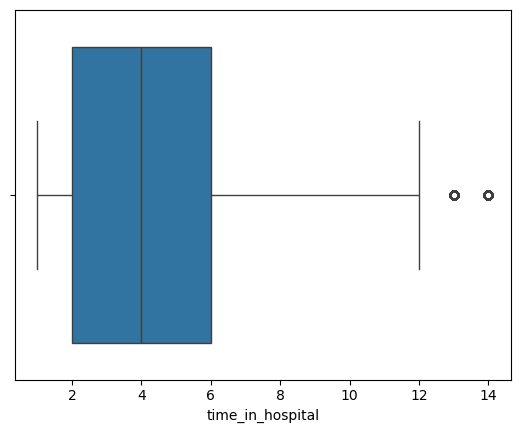

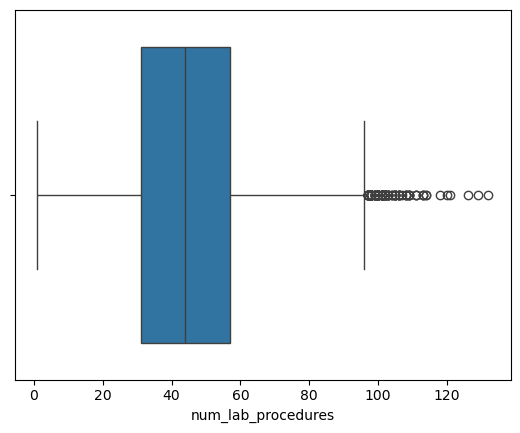

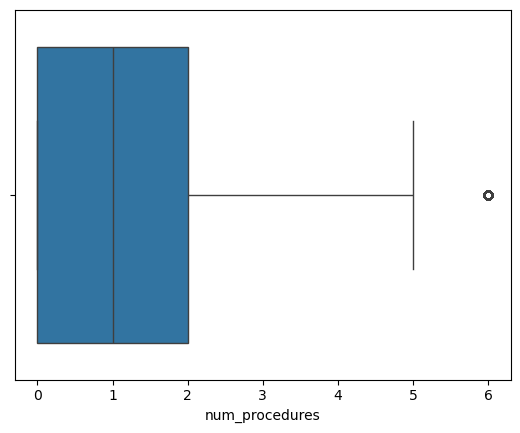

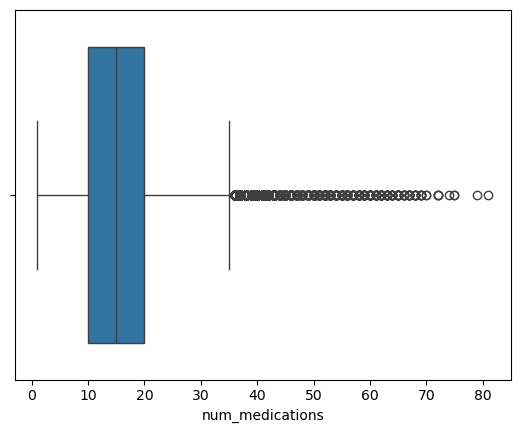

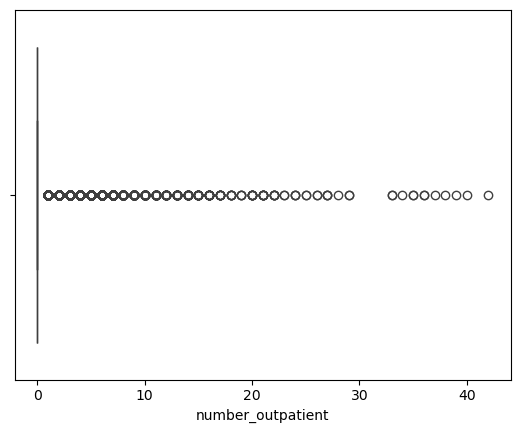

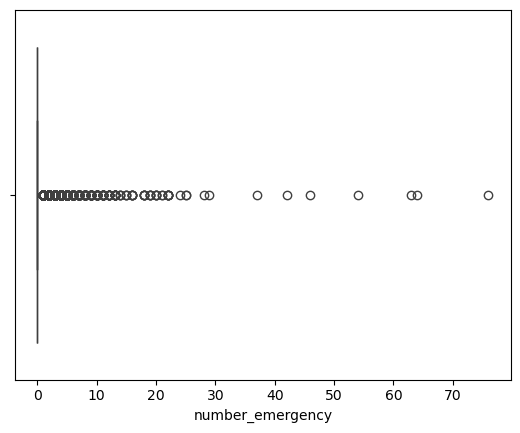

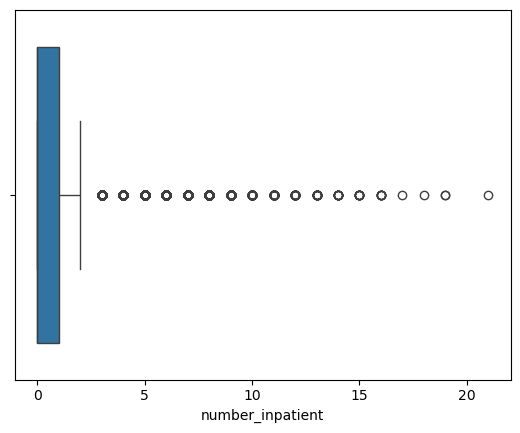

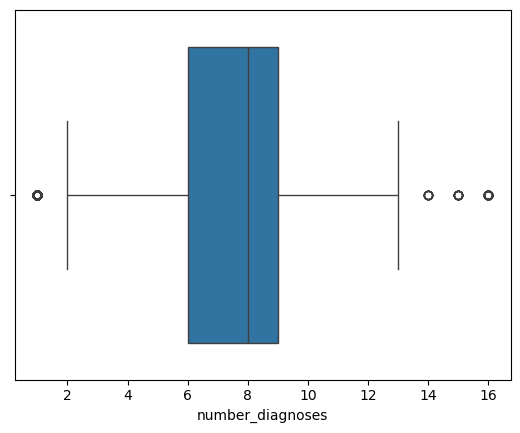

In [72]:
for i in num_col:
    eda.plot_boxplot(i)

In [70]:
for i in num_col:
    print(i)
    print(eda.outlier_report(i))

time_in_hospital
{'Q1': np.float64(2.0), 'Q3': np.float64(6.0), 'IQR': np.float64(4.0), 'Lower Bound': np.float64(-4.0), 'Upper Bound': np.float64(12.0), 'Outlier Count': 2252, 'Outlier Percentage': 2.21}
num_lab_procedures
{'Q1': np.float64(31.0), 'Q3': np.float64(57.0), 'IQR': np.float64(26.0), 'Lower Bound': np.float64(-8.0), 'Upper Bound': np.float64(96.0), 'Outlier Count': 143, 'Outlier Percentage': 0.14}
num_procedures
{'Q1': np.float64(0.0), 'Q3': np.float64(2.0), 'IQR': np.float64(2.0), 'Lower Bound': np.float64(-3.0), 'Upper Bound': np.float64(5.0), 'Outlier Count': 4954, 'Outlier Percentage': 4.87}
num_medications
{'Q1': np.float64(10.0), 'Q3': np.float64(20.0), 'IQR': np.float64(10.0), 'Lower Bound': np.float64(-5.0), 'Upper Bound': np.float64(35.0), 'Outlier Count': 2557, 'Outlier Percentage': 2.51}
number_outpatient
{'Q1': np.float64(0.0), 'Q3': np.float64(0.0), 'IQR': np.float64(0.0), 'Lower Bound': np.float64(0.0), 'Upper Bound': np.float64(0.0), 'Outlier Count': 16739, 

so cols are considered good in term of outliers are: time_in_hospital, num_of_lab-procedures, num_of_procudures, num_medication, num_diognosis, num_patients, in_patients , emegecy

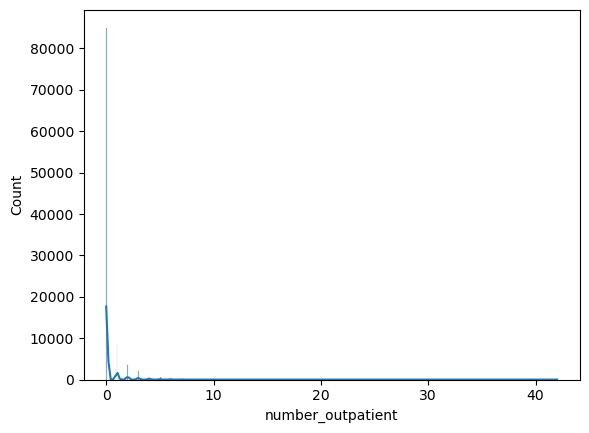

In [71]:
eda.plot_histogram("number_outpatient")

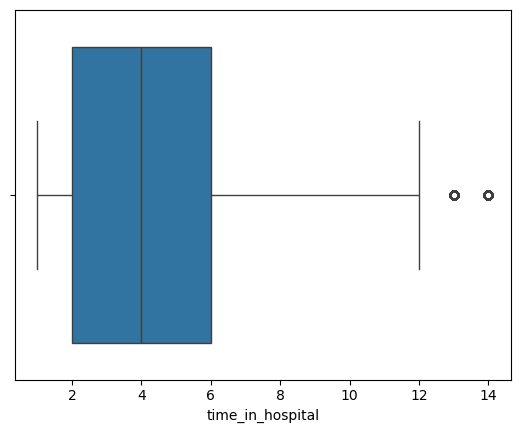

In [26]:
eda.plot_boxplot("time_in_hospital")

In [4]:
(df["time_in_hospital"] > 12).sum()

np.int64(2252)

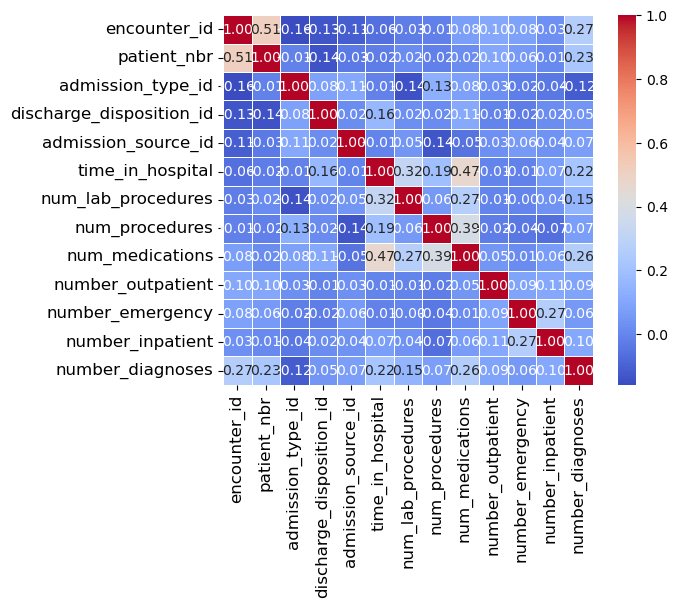

In [83]:
num_df = df.select_dtypes(include="number")
corr = num_df.corr()
plt.Figure(figsize=(30,35))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", linewidths=0.5, square=True, cbar= True)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.show()

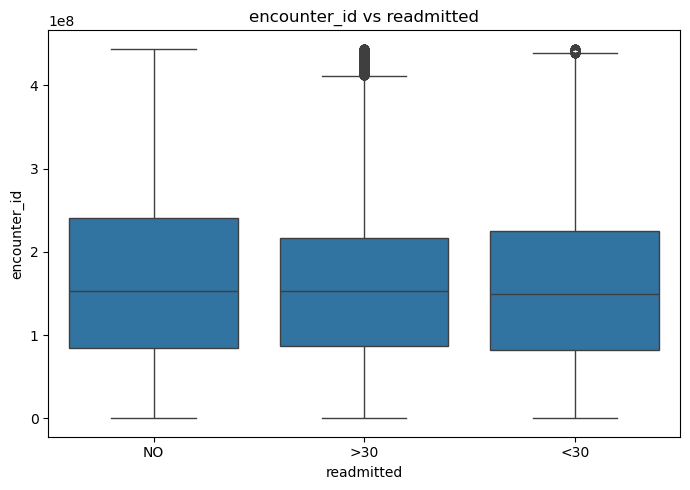

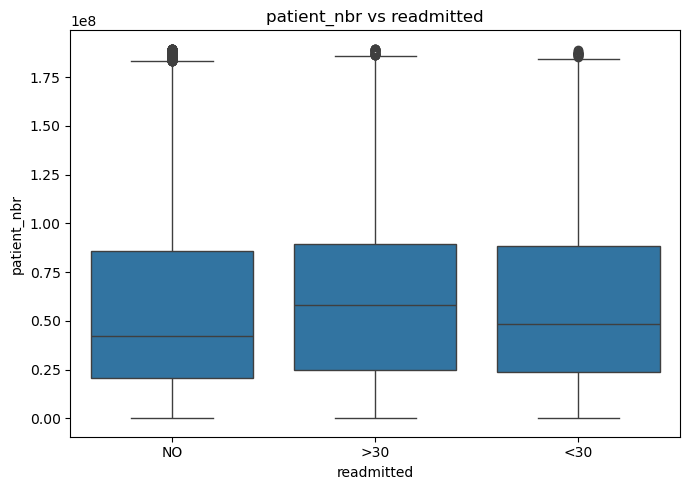

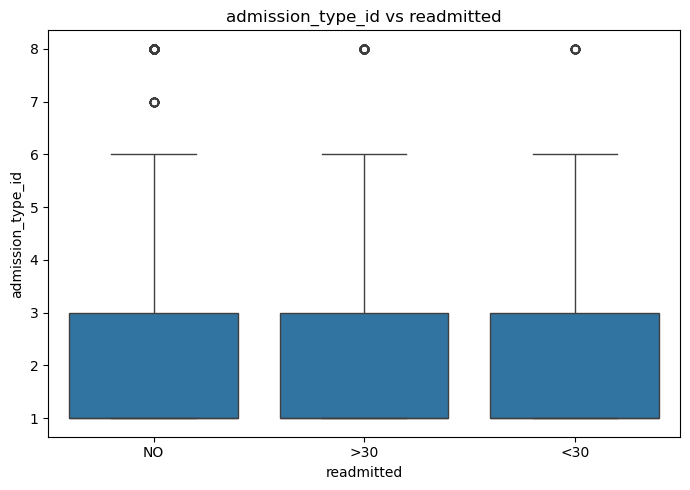

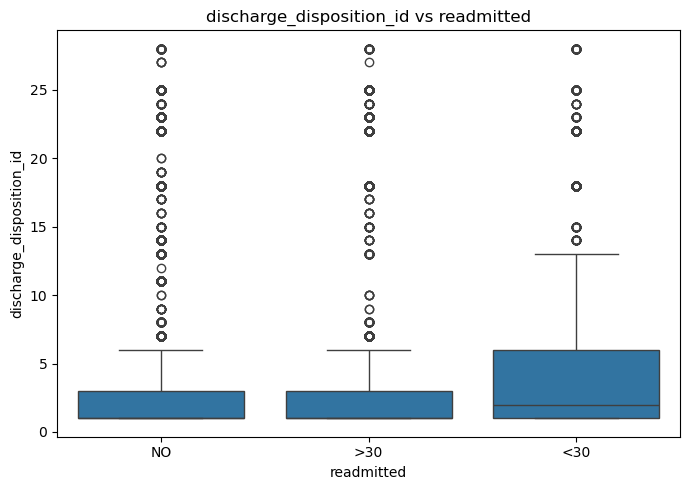

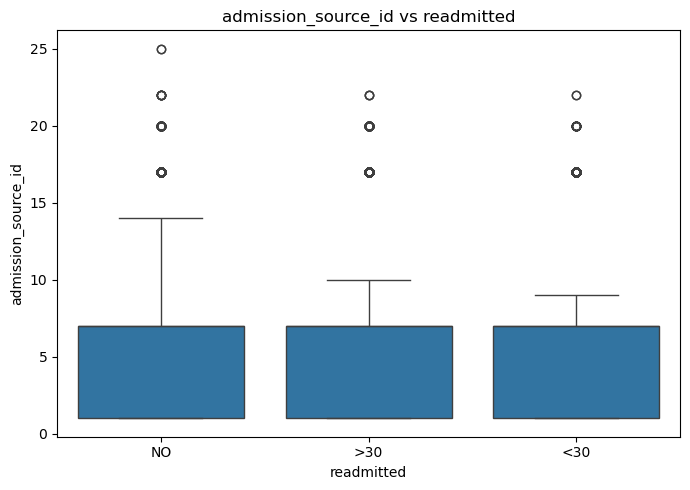

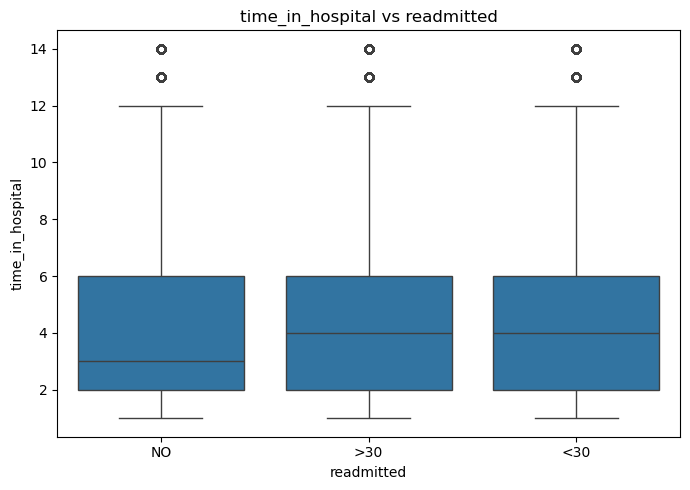

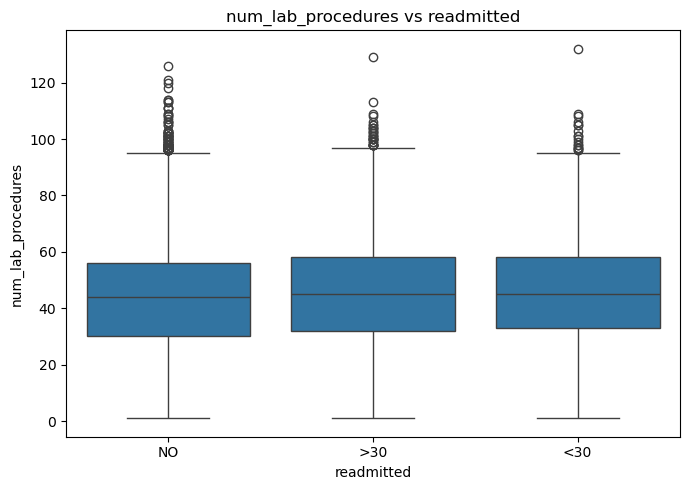

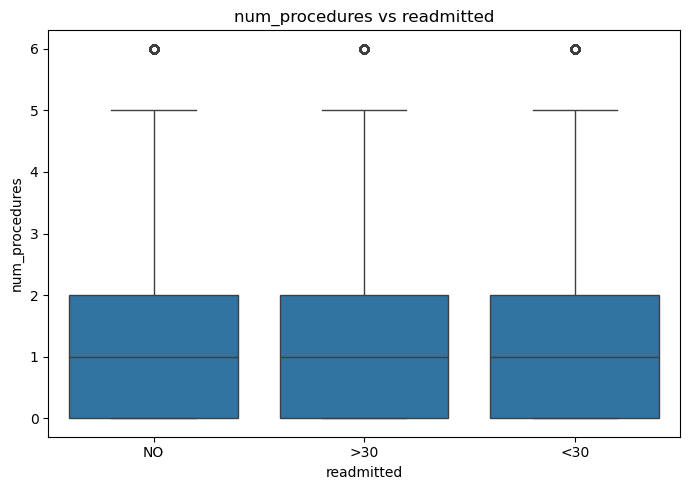

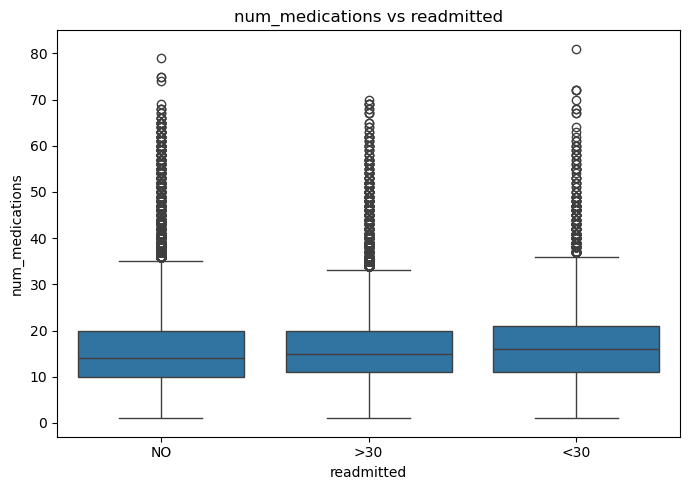

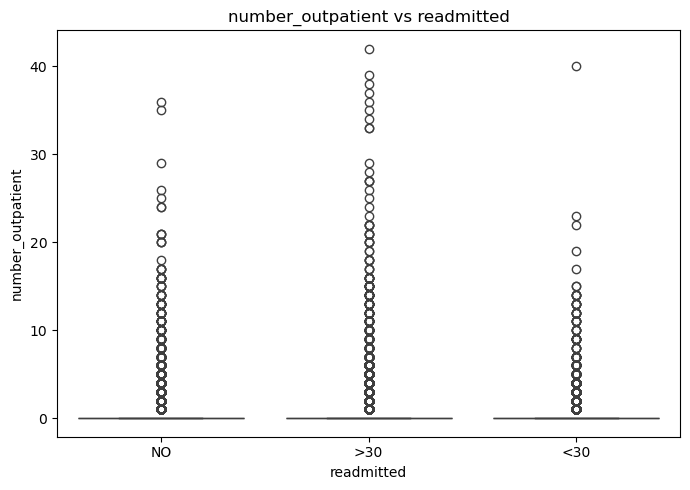

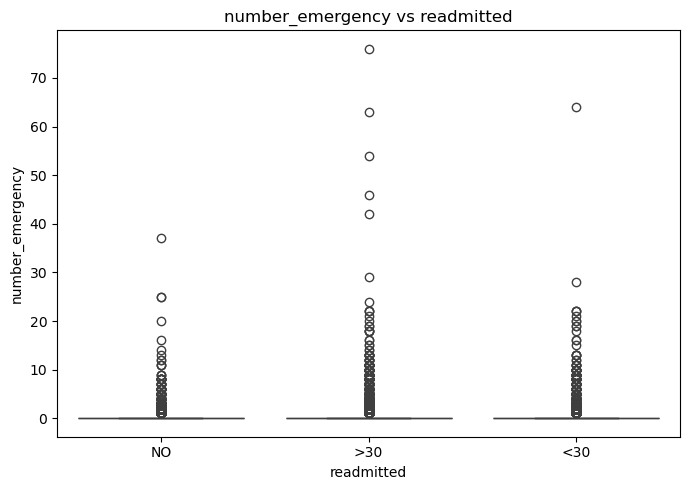

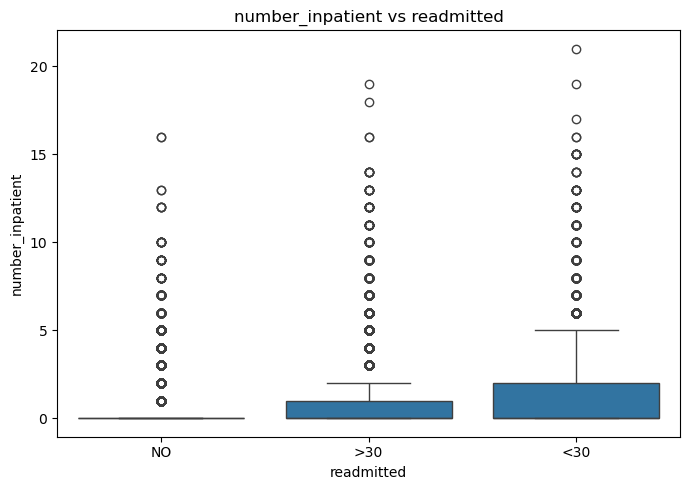

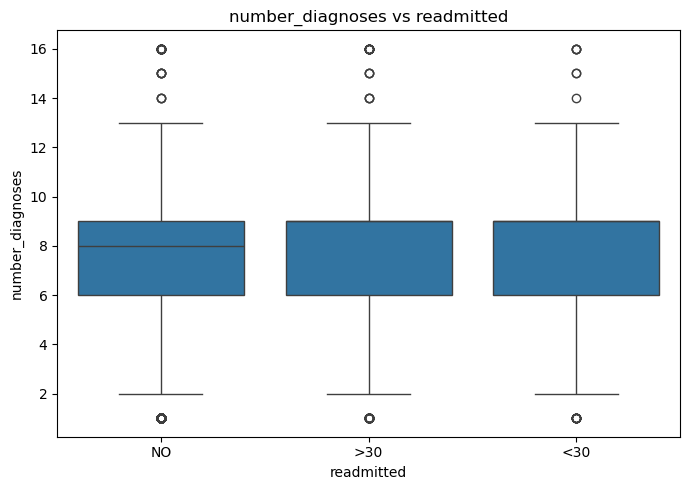

In [84]:
target = "readmitted"

numeric_cols = df.select_dtypes(include="number").columns

for feature in numeric_cols:
    plt.figure(figsize=(7, 5))

    sns.boxplot(
        data=df,
        x=target,
        y=feature
    )

    plt.title(f"{feature} vs {target}")
    plt.tight_layout()
    plt.show()

C:\Users\ELITEBOOK\AppData\Local\Temp\ipykernel_21560\3822561540.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df.select_dtypes(include="object").columns


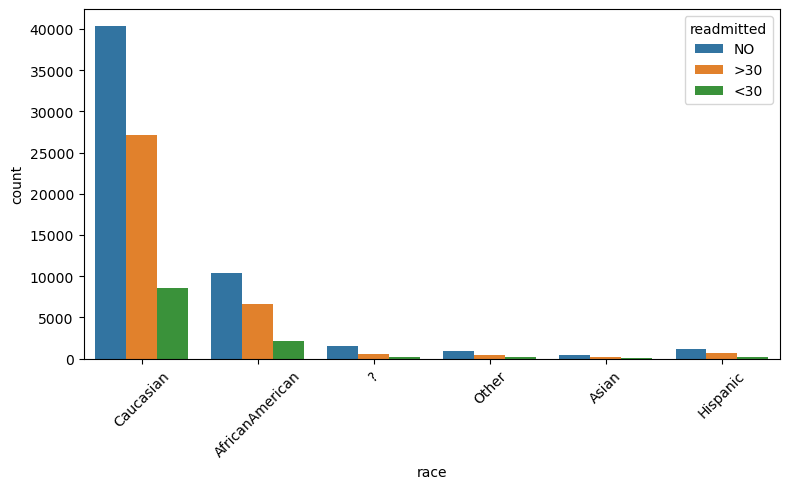

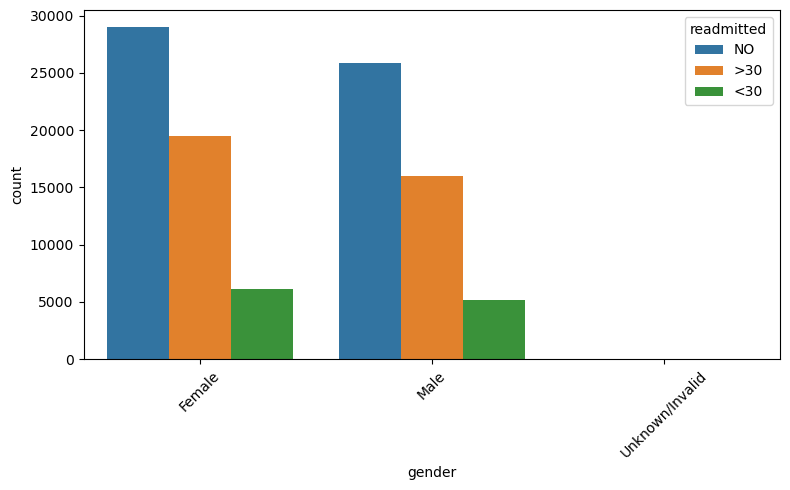

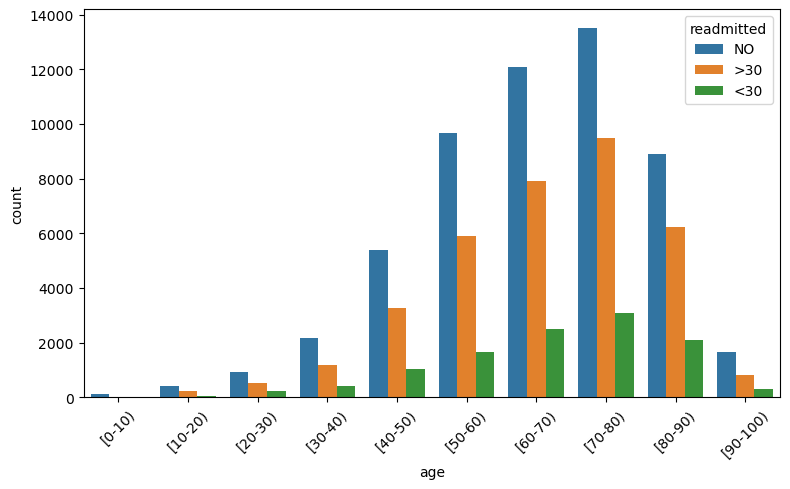

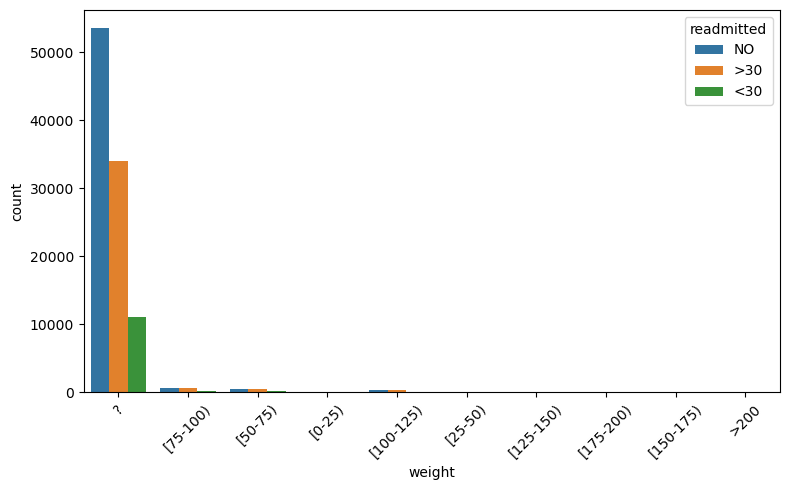

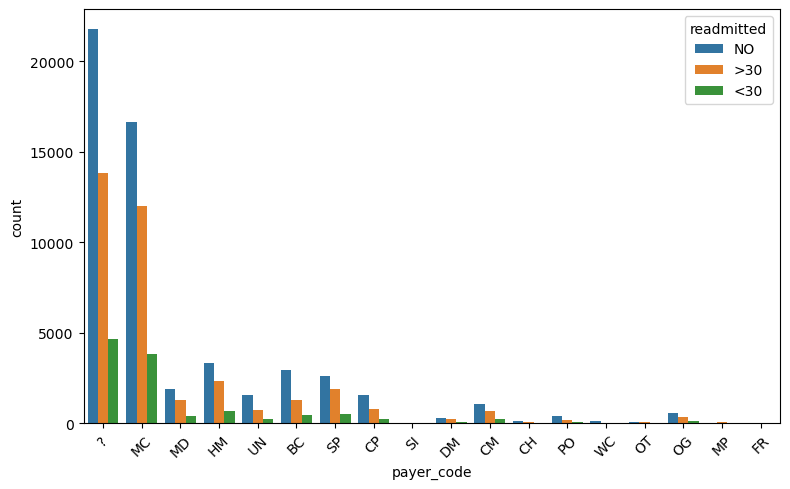

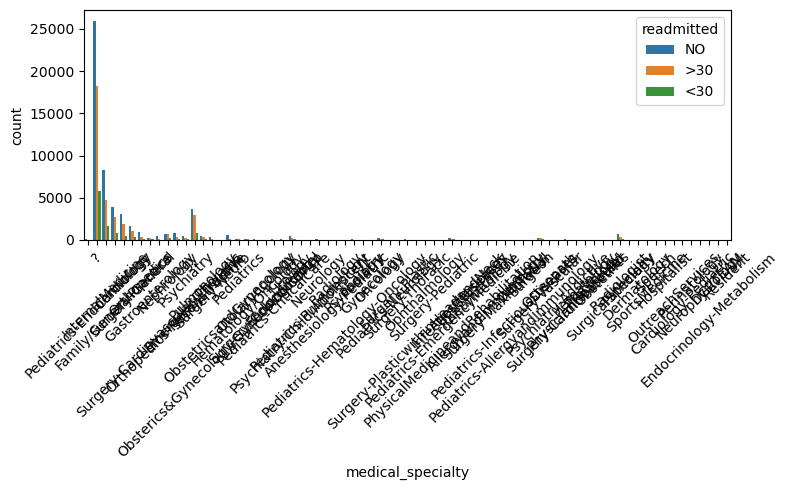

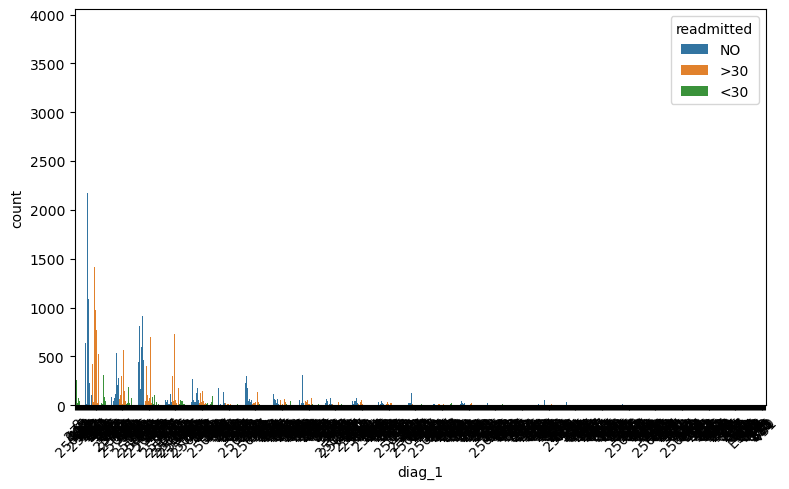

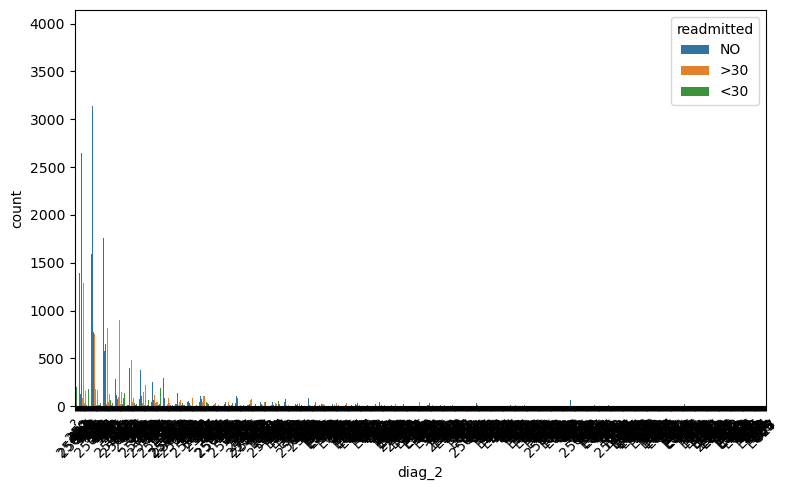

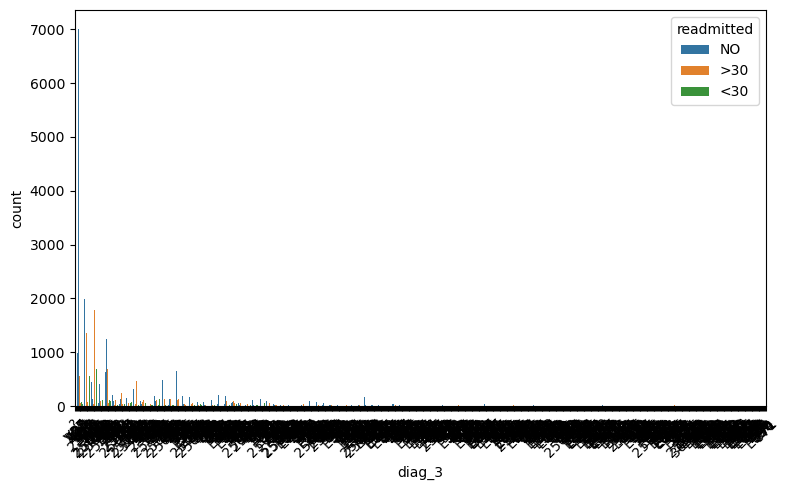

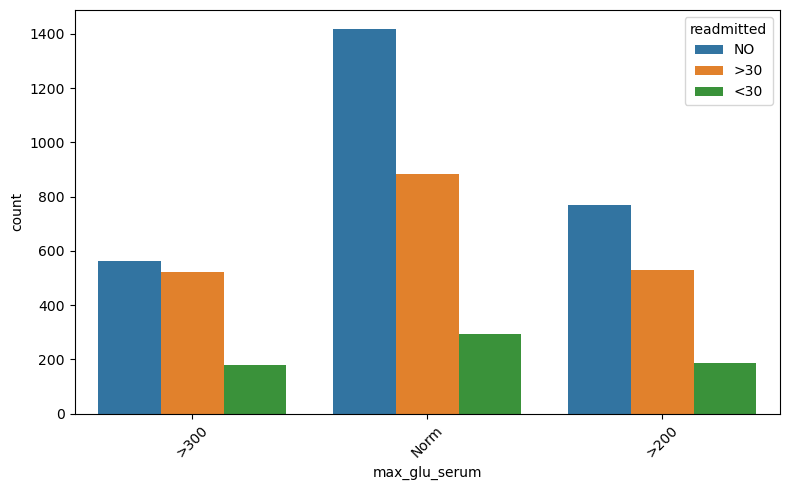

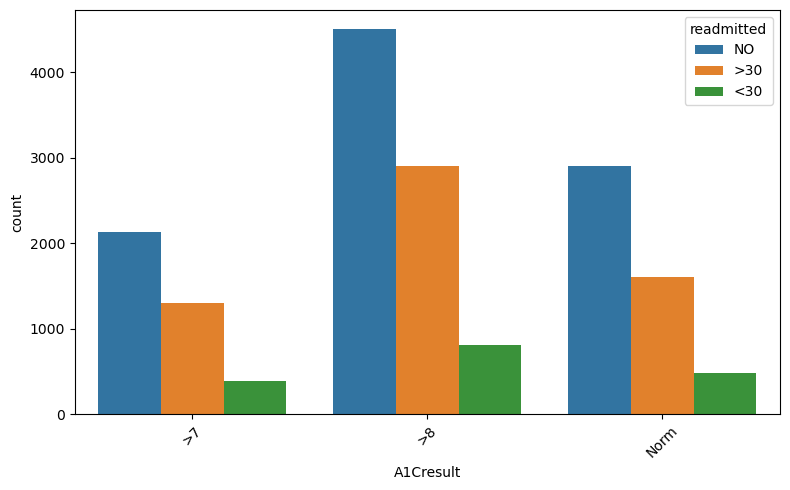

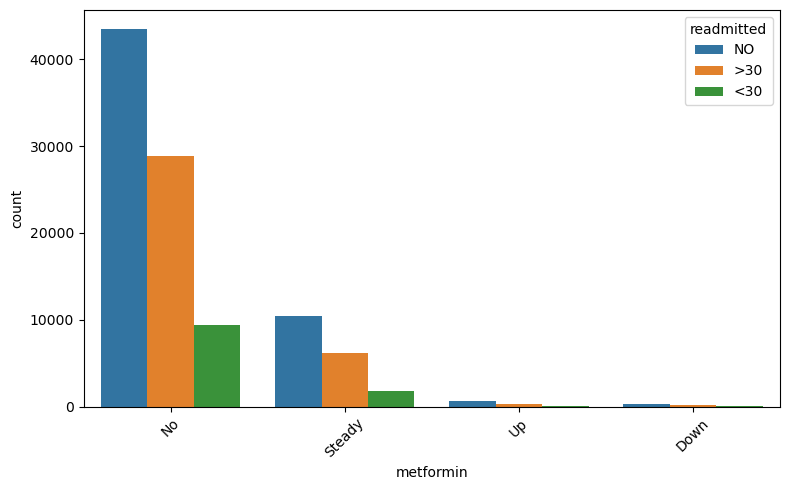

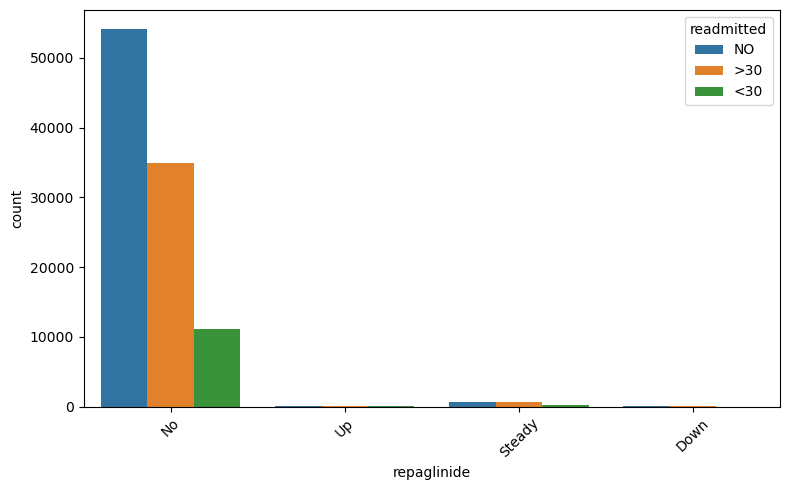

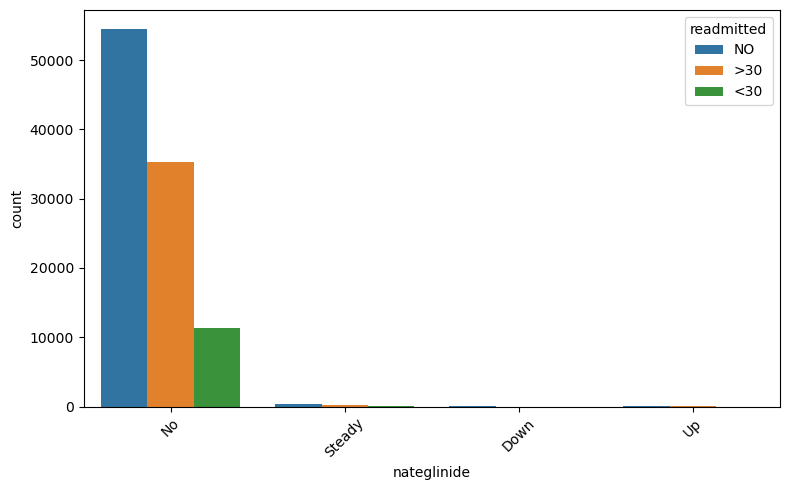

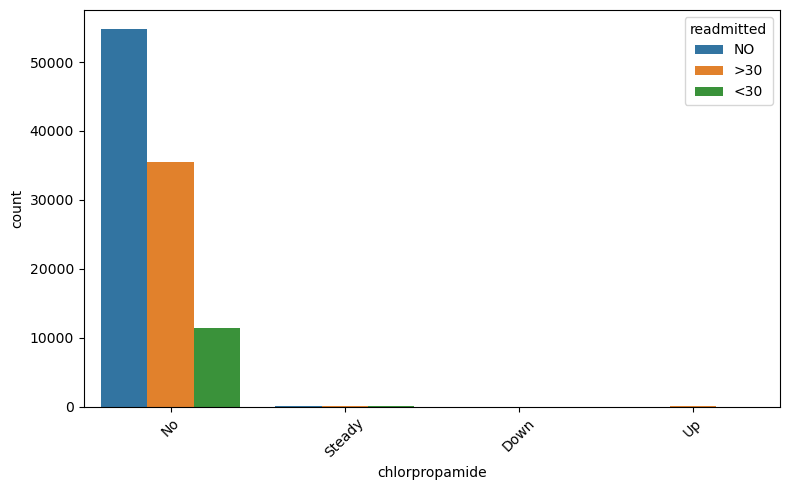

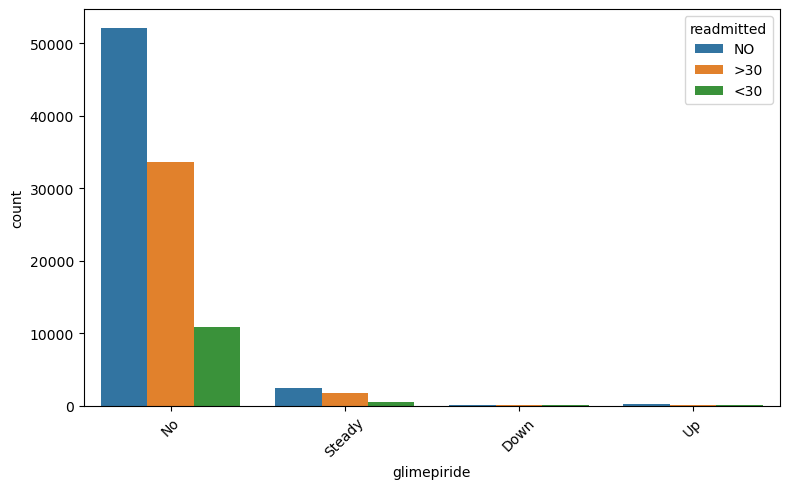

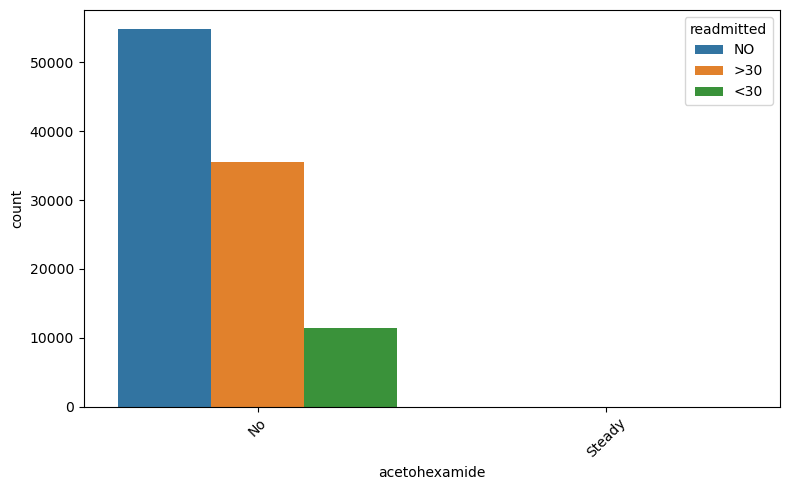

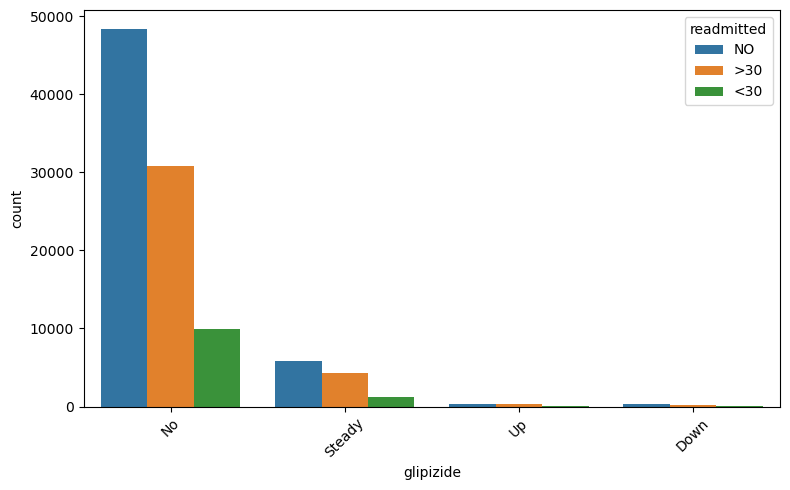

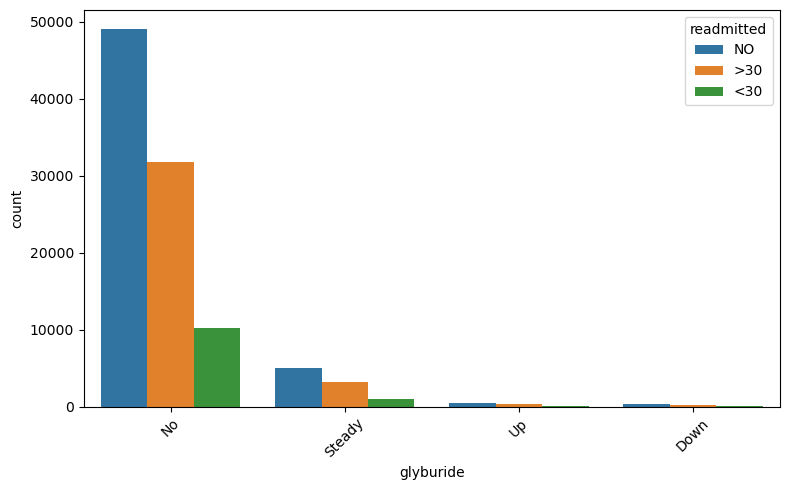

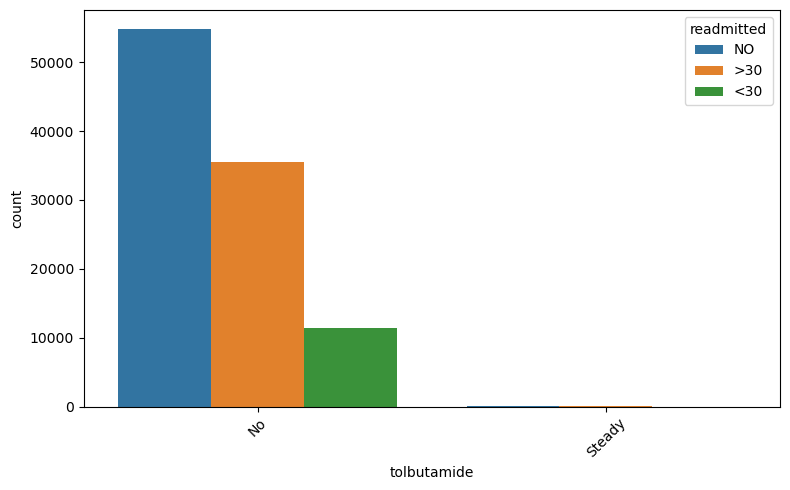

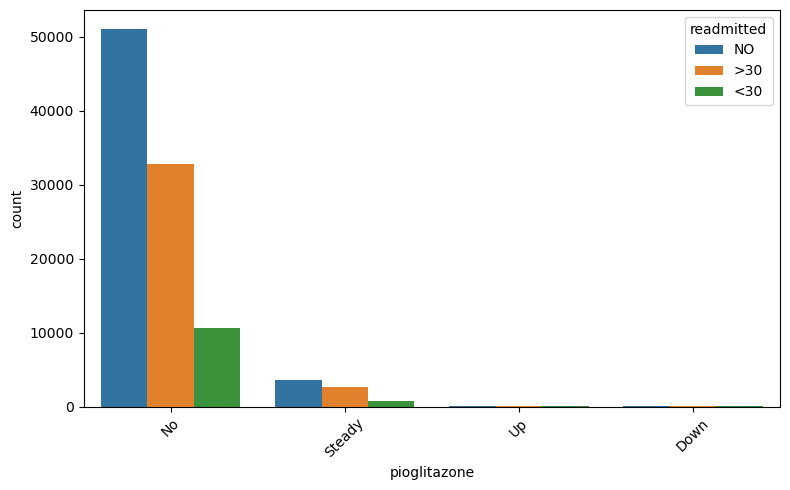

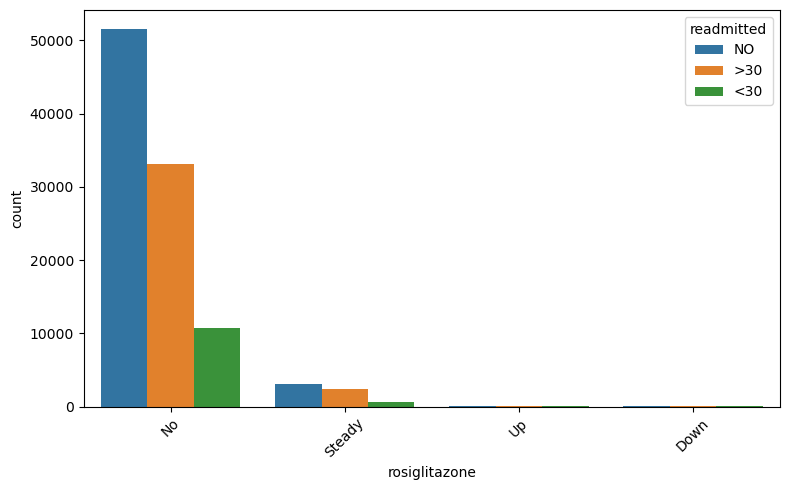

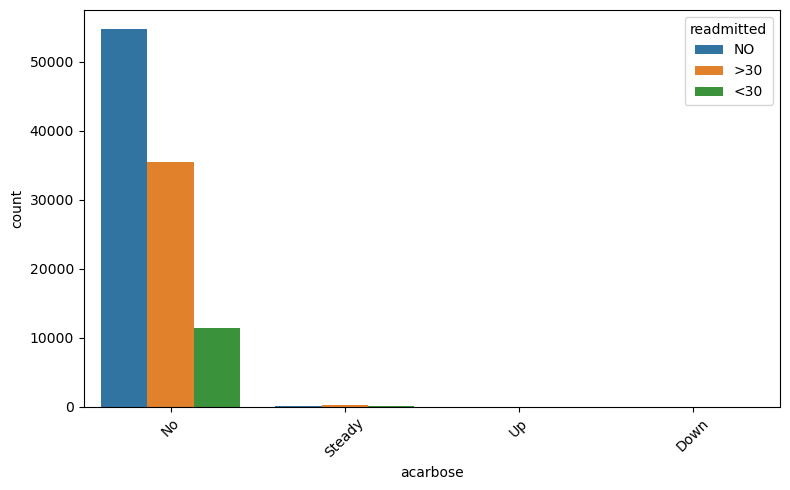

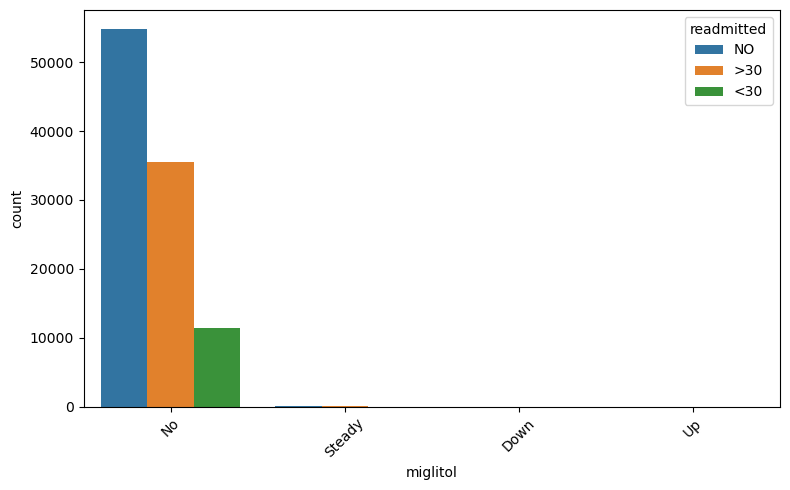

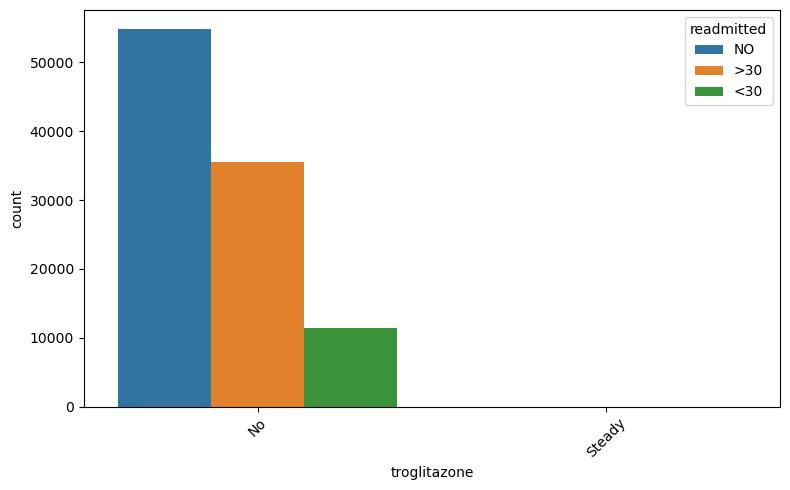

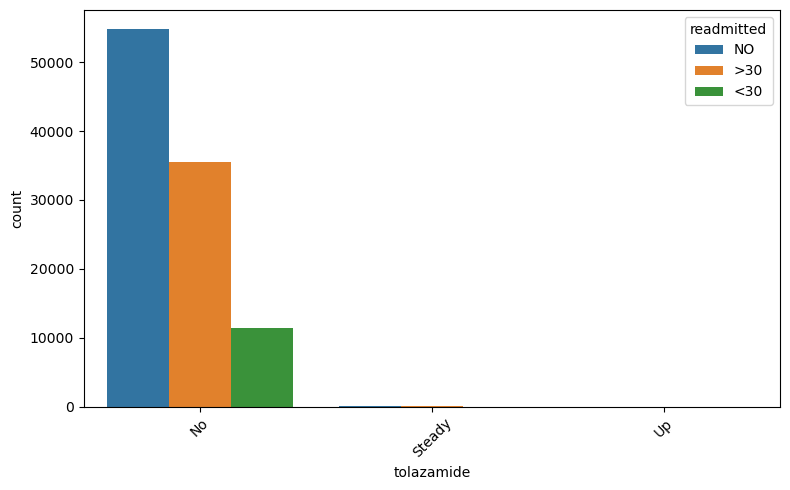

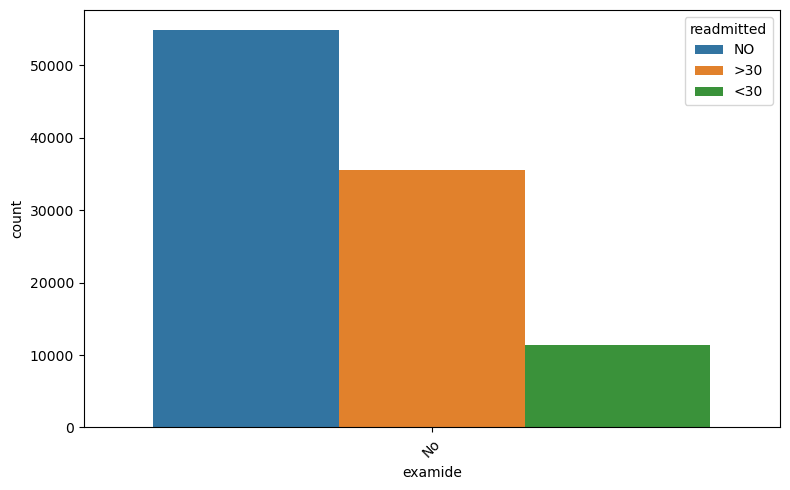

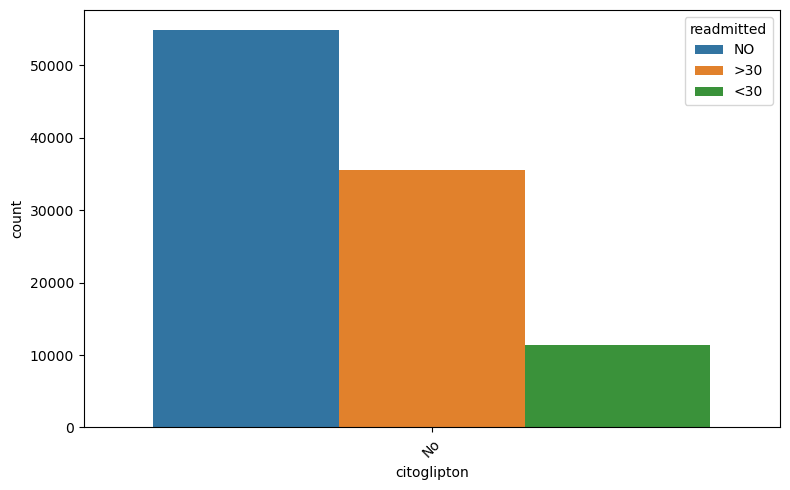

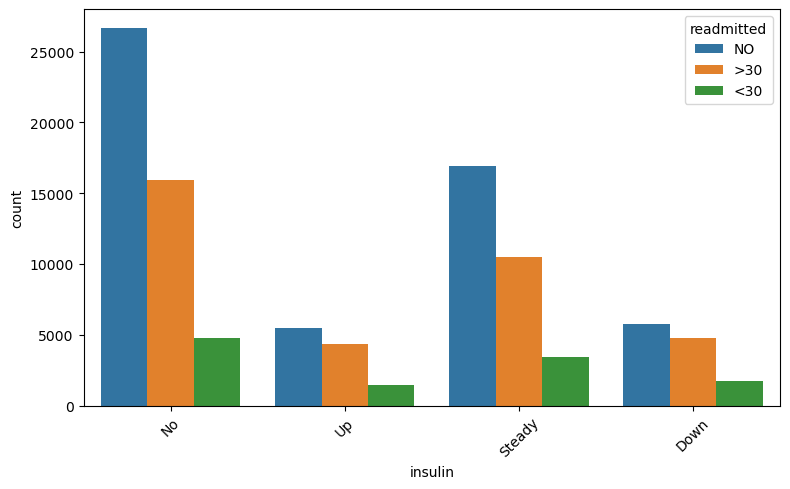

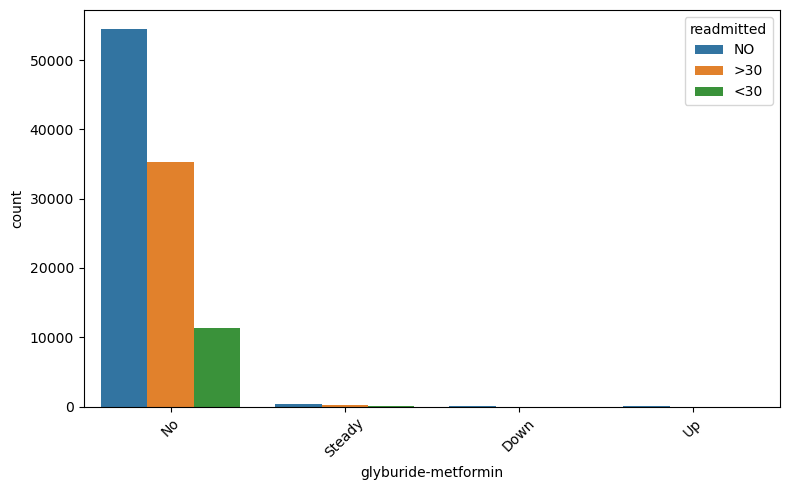

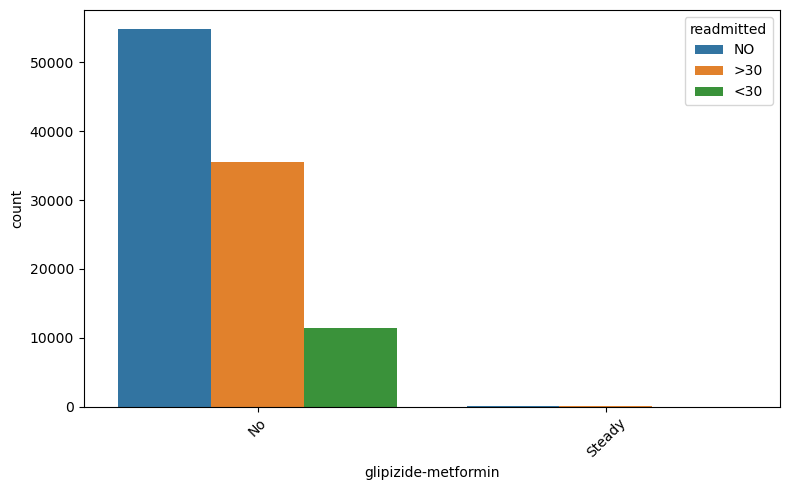

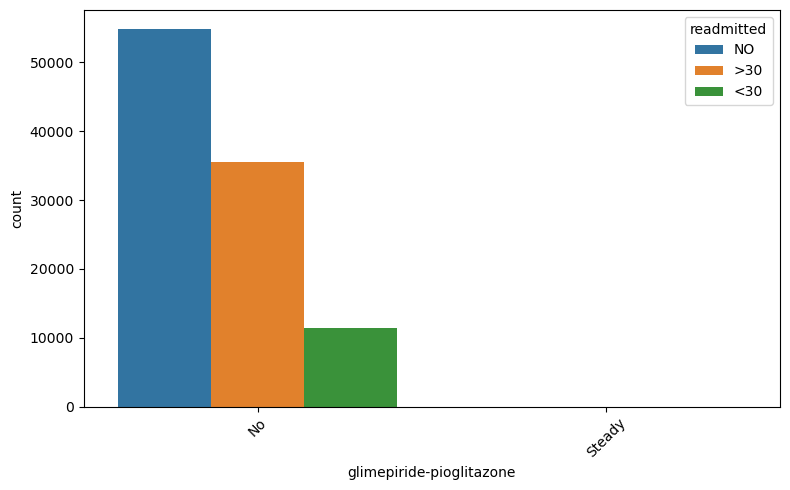

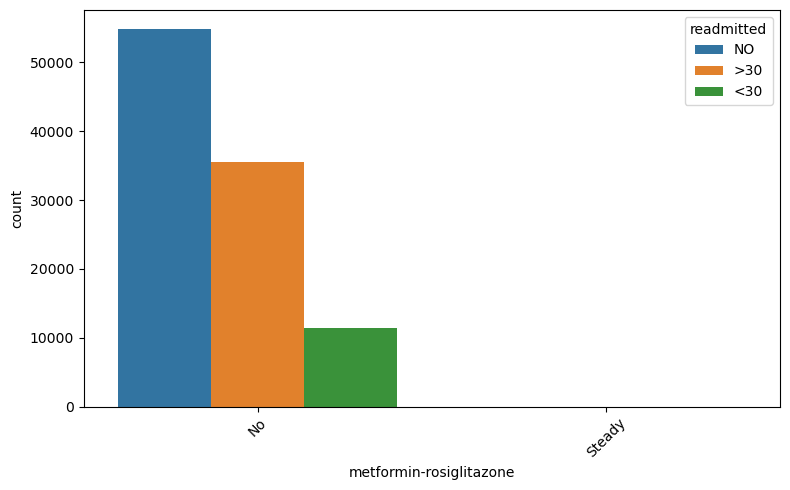

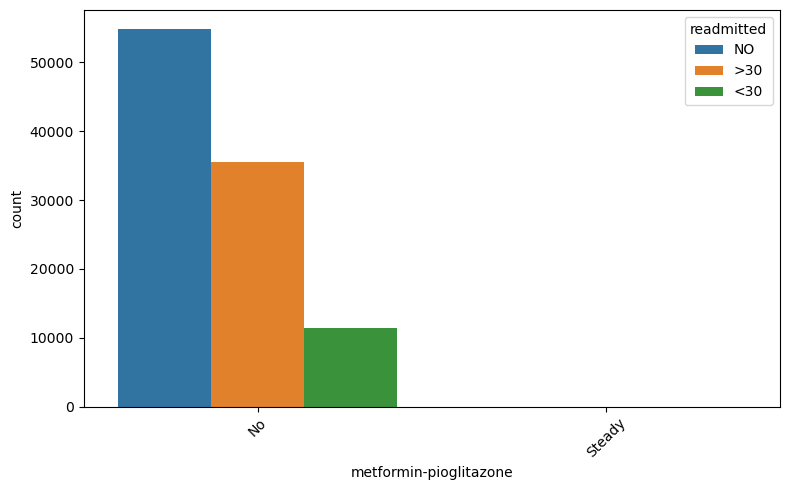

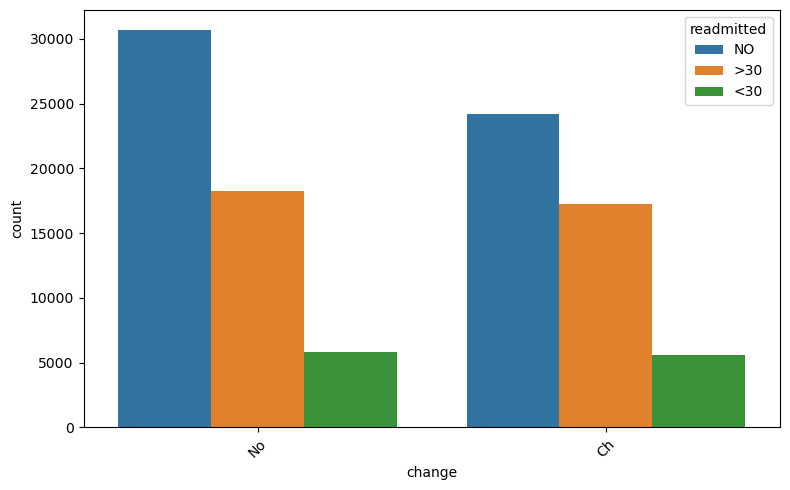

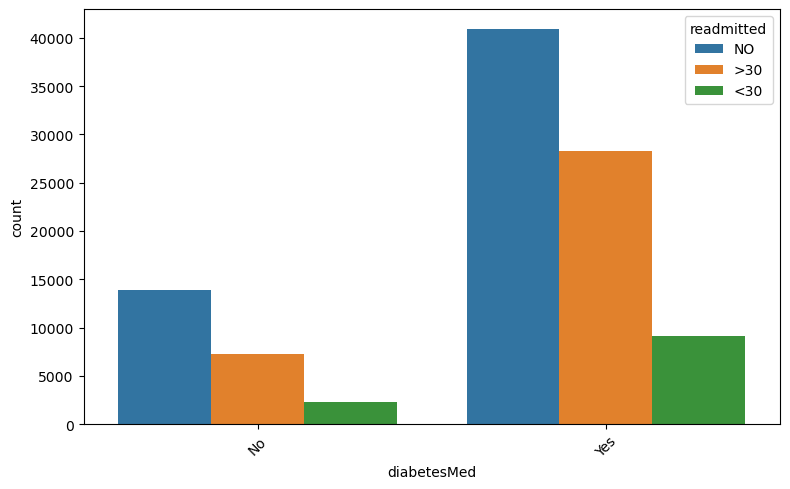

In [85]:
categorical_cols = df.select_dtypes(include="object").columns

for feature in categorical_cols:

    if feature == target:
        continue

    plt.figure(figsize=(8, 5))

    sns.countplot(
        data=df,
        x=feature,
        hue=target
    )

    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

In [86]:
df['time_in_hospital'].describe()

count    101766.000000
mean          4.395987
std           2.985108
min           1.000000
25%           2.000000
50%           4.000000
75%           6.000000
max          14.000000
Name: time_in_hospital, dtype: float64